# Q8.

```{admonition}
:class: note
Fit some of the non-linear models investigated in this chapter to the `Auto` data set. Is there evidence for non-linear relationships in this data set? Create some informative plots to justify your answer.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, train_test_split
#from sklearn.feature_extraction import

In [42]:
import statsmodels.api as sm

In [16]:
import seaborn as sns

In [17]:
from pygam import f as gmf, s as gms, LinearGAM

In [39]:
rng = np.random.default_rng(1728)

def best_low_complexity(cv_results):
    best_score_idx = np.argmax(cv_results["mean_test_score"])
    thresh = cv_results["mean_test_score"][best_score_idx] - cv_results["std_test_score"][best_score_idx]/10
    candidate_idx = np.flatnonzero(cv_results["mean_test_score"] >= thresh)
    best_idx = candidate_idx[
        cv_results["param_poly__degree"][candidate_idx].argmin()
    ]
    return best_idx

def gamfit(df:pd.DataFrame,cols:list,target:str) -> LinearGAM:
    y = df[target]
    X = df[cols]
    categorical_cols = [col for col in X.select_dtypes(include=['category'])]
    terms = [gmf(i) if col in categorical_cols else gms(i) for i,col in enumerate(cols)]
    gam = LinearGAM(np.sum(terms))
    return gam.gridsearch(X,y,lam=np.exp(rng.random(size=(100, len(cols))) * 6 - 3))

def gamplot(gam:LinearGAM,df:pd.DataFrame,cols:list,target:str):
    fig, axs = plt.subplots(1, len(cols),figsize=(20,4))
    for i, ax in enumerate(axs):
        XX = gam.generate_X_grid(term=i)
        ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
        ax.plot(
            XX[:, i], gam.partial_dependence(term=i, X=XX, width=0.95)[1], c="r", ls="--"
        )
        ax.set_title(cols[i])

In [4]:
auto = pd.read_csv('../../ALL CSV FILES - 2nd Edition/Auto.csv',na_values={'?',np.nan},index_col='name')

In [5]:
auto.sample(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
volkswagen dasher,26.0,4,79.0,67.0,1963,15.5,74,2
dodge colt hatchback custom,35.7,4,98.0,80.0,1915,14.4,79,1
vw rabbit custom,31.9,4,89.0,71.0,1925,14.0,79,2


In [12]:
auto.loc[auto.isna().any(axis=1)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
ford pinto,25.0,4,98.0,NaN,2046,19.0,71,1
ford maverick,21.0,6,200.0,NaN,2875,17.0,74,1
renault lecar deluxe,40.9,4,85.0,NaN,1835,17.3,80,2
ford mustang cobra,23.6,4,140.0,NaN,2905,14.3,80,1
renault 18i,34.5,4,100.0,NaN,2320,15.8,81,2


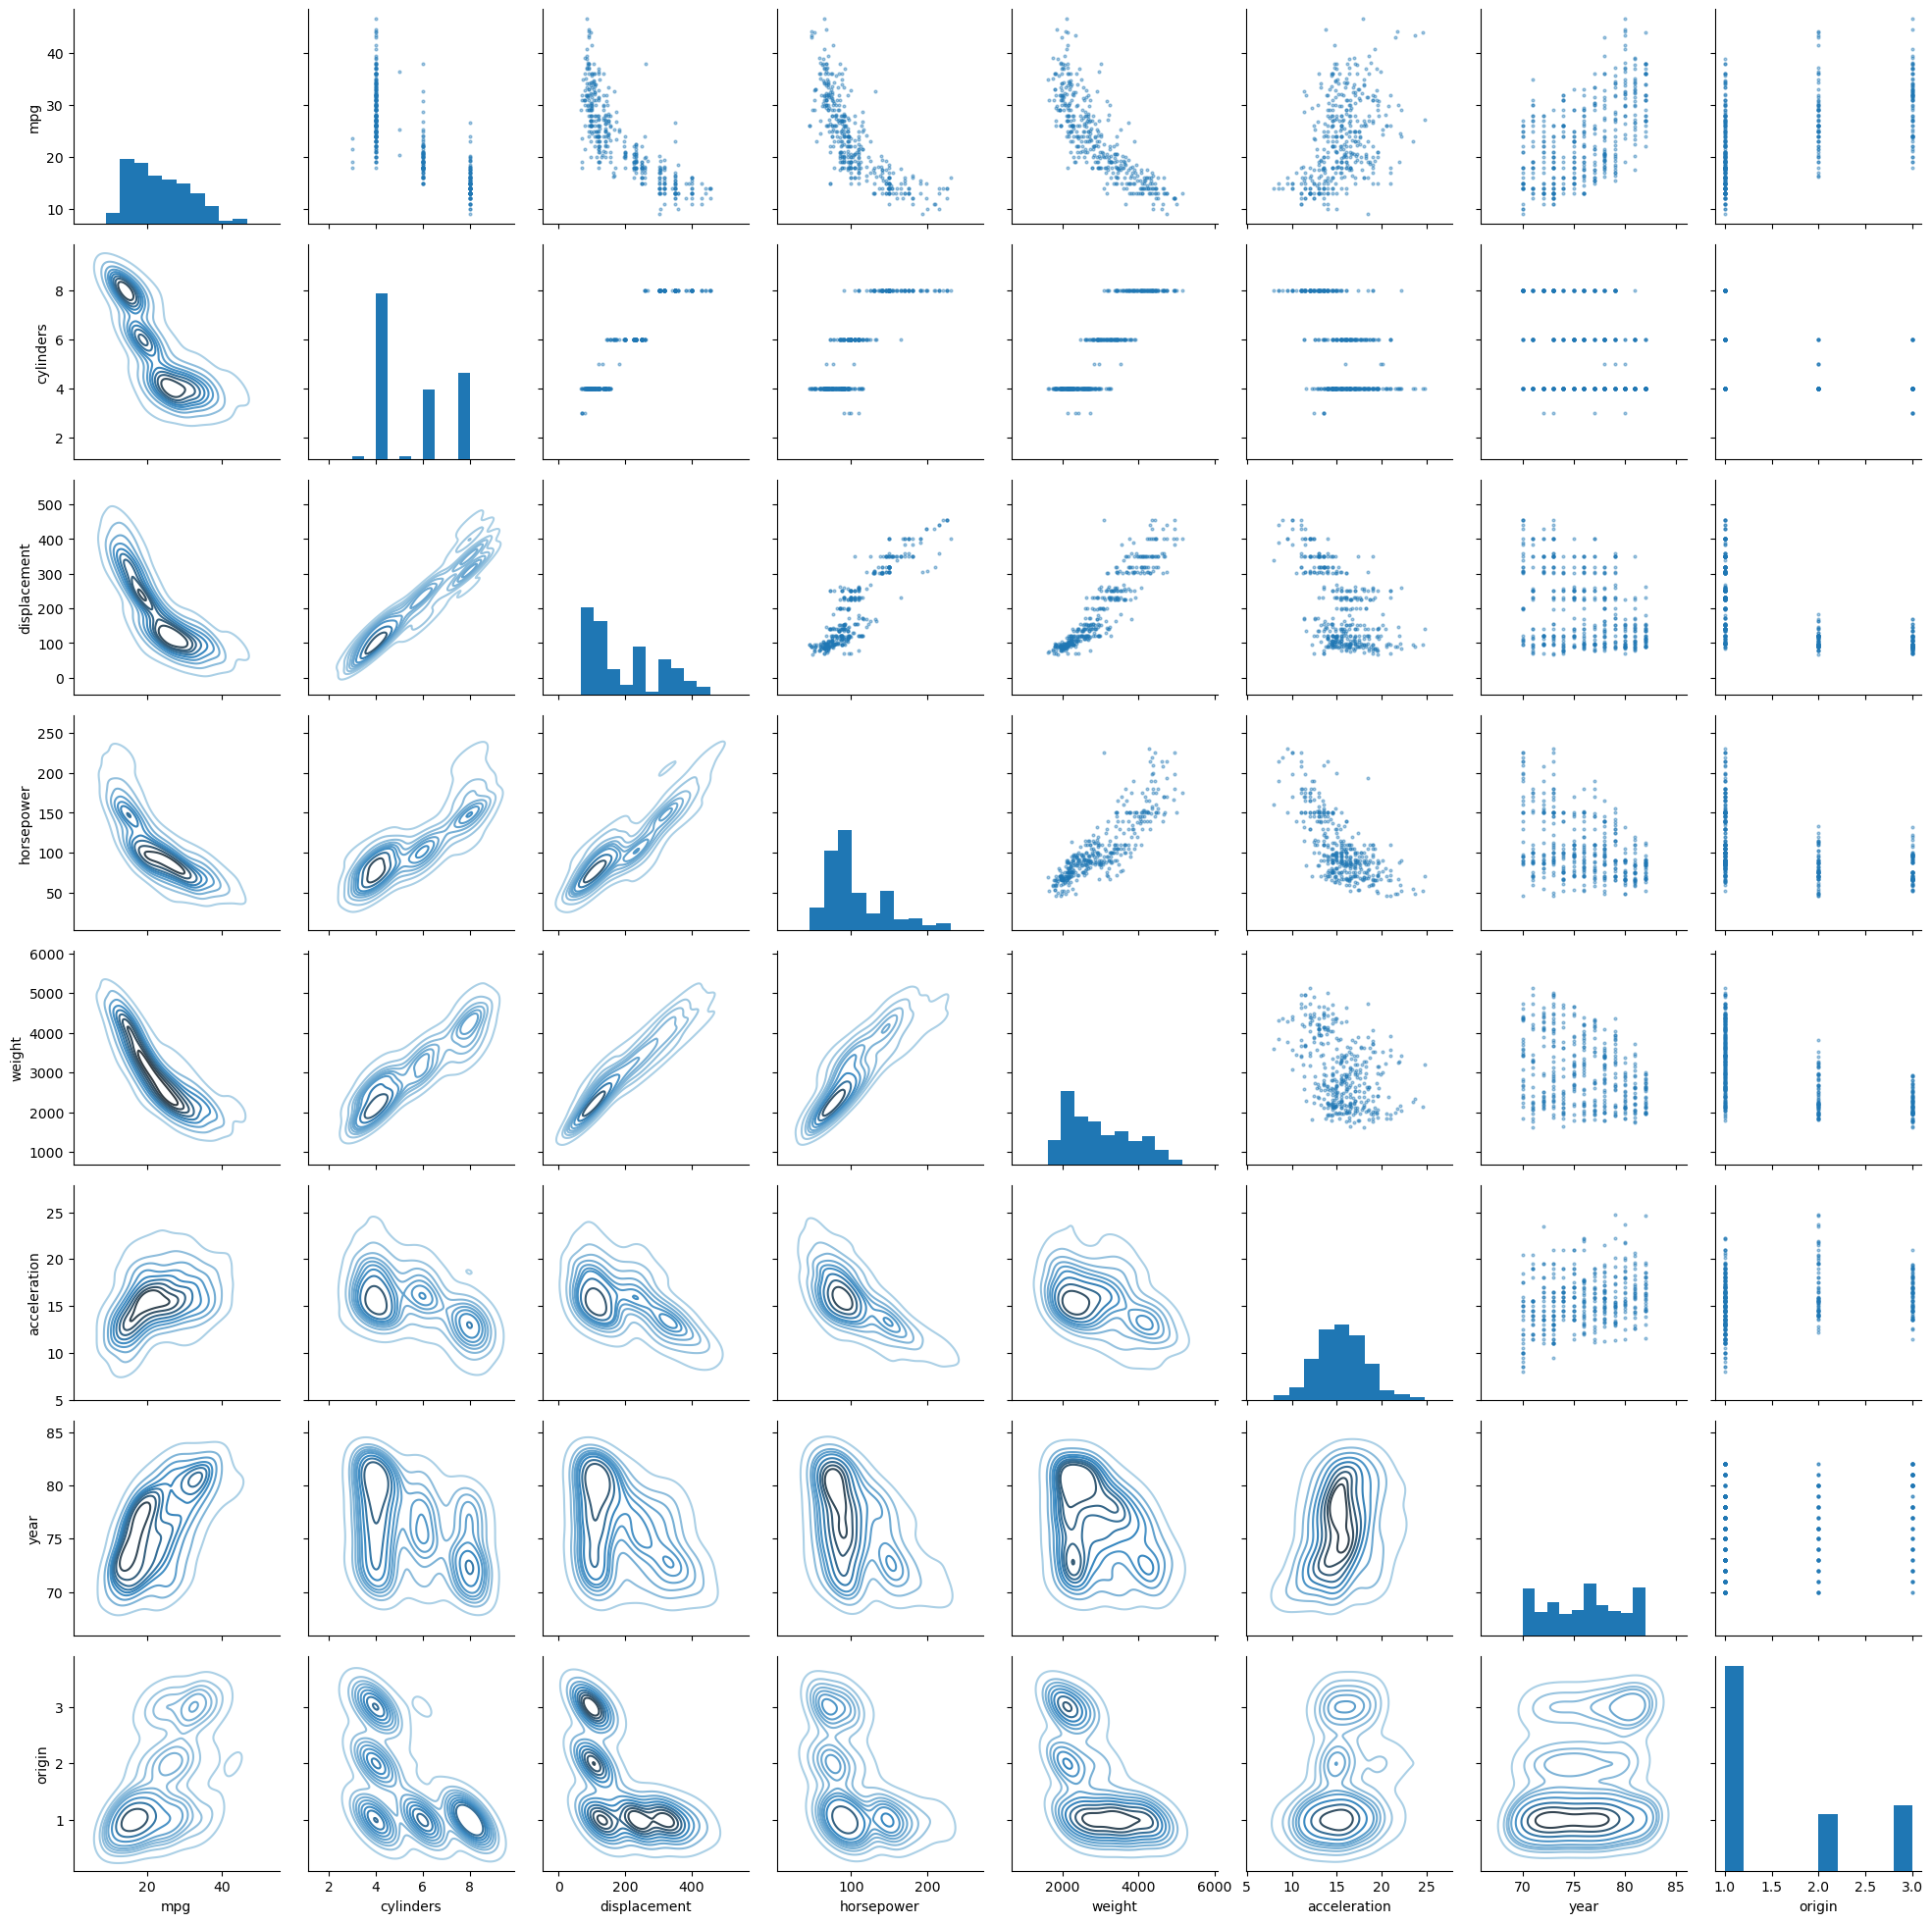

In [21]:
auto_no_na = auto.dropna()
pairgrid = sns.PairGrid(auto_no_na)
pairgrid.map_upper(plt.scatter,s=4,alpha=0.4)
pairgrid.map_diag(plt.hist)
pairgrid.map_lower(sns.kdeplot,cmap='Blues_d')
plt.show()

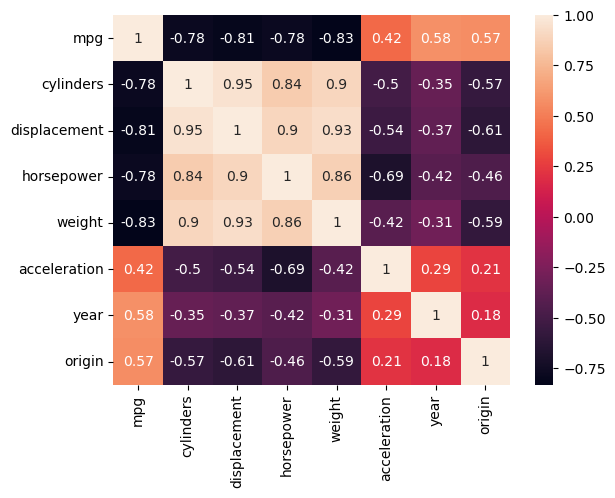

In [23]:
sns.heatmap(auto_no_na.corr(),annot=True);

In [146]:
auto_no_na[['cylinders','year','origin']] = auto_no_na[['cylinders','year','origin']].astype('category')
auto_train, auto_test = train_test_split(auto_no_na,shuffle=True,stratify=auto_no_na['year'])

```{admonition} :class: note
(a) Perform polynomial regression to predict wage using age. Use cross-validation to select the optimal degree $d$ for the polynomial. What degree was chosen, and how does this compare to the results of hypothesis testing using ANOVA? Make a plot of the resulting polynomial fit to the data.

In [147]:
X = auto_train[['horsepower']]
y = auto_train['mpg']

pipe = Pipeline(
    [
        ('poly',PolynomialFeatures(include_bias=True)),('lr',LinearRegression(fit_intercept=False))
    ]

)
inner_cv = KFold(shuffle=True,random_state=1728,n_splits=10)
outer_cv = KFold(shuffle=True,random_state=1729,n_splits=10)
degrees = np.arange(5)

gridsearch = GridSearchCV(pipe,{'poly__degree':degrees},scoring='neg_mean_squared_error',cv=inner_cv,n_jobs=-1,refit=best_low_complexity)
#gridsearch = GridSearchCV(pipe,{'poly__degree':degrees},scoring='neg_mean_squared_error',cv=inner_cv,n_jobs=-1)
cv_mse = -cross_val_score(gridsearch,X,y,cv=outer_cv).mean()

gridsearch.fit(X,y)
best_degree = gridsearch.best_params_['poly__degree']

print(f'CV average MSE: {cv_mse:.4f}')
print(f'Degree used: {best_degree}')

CV average MSE: 18.5271
Degree used: 2


In [148]:
Xs = [PolynomialFeatures(include_bias=True,degree=d).fit_transform(X) for d in range(4)]
ano_res = sm.stats.anova_lm(*[sm.OLS(y,x).fit() for x in Xs]).replace(np.nan,-np.inf)
print(ano_res)
best_anova_degree = ano_res[ano_res['Pr(>F)']>0.05].index[0]-1
print(f'Degree chosen by ANOVA: {best_anova_degree}')

   df_resid           ssr  df_diff       ss_diff           F        Pr(>F)
0     293.0  17429.566395      0.0          -inf        -inf          -inf
1     292.0   6570.218985      1.0  1.085935e+04  597.401571  1.355744e-72
2     291.0   5273.966378      1.0  1.296253e+03   71.310302  1.468664e-15
3     290.0   5271.514009      1.0  2.452369e+00    0.134911  7.136611e-01
Degree chosen by ANOVA: 2


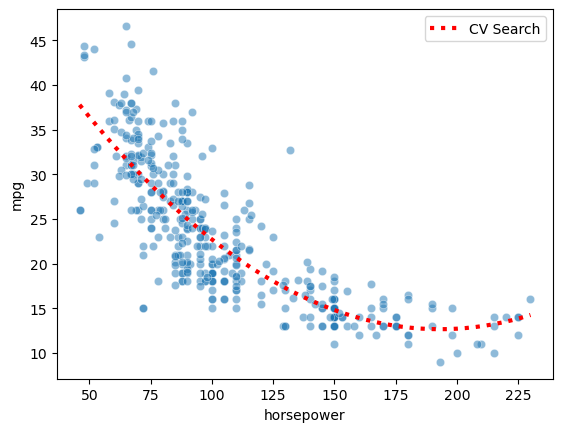

In [149]:
pipe.named_steps['poly'].degree = best_degree
pipe.fit(X,y)
xs = np.linspace(X.min().values[0],X.max().values[0])
xs_cv = np.array([[x**d for d in range(best_degree+1)] for x in xs])
lr_coef = pipe.named_steps['lr'].coef_
ys_cv = xs_cv @ lr_coef
plt.plot(xs,ys_cv,'r:',linewidth=3,label='CV Search')

sns.scatterplot(auto_no_na,x='horsepower',y='mpg',alpha=0.5)
plt.show()

In [150]:
ho_pred = pipe.predict(auto_train[['horsepower']])
ho_mse = mean_squared_error(auto_train['mpg'],ho_pred)
print(f'Holdout MSE: {ho_mse}')

Holdout MSE: 17.938661148211896


```{admonition} :class: note
(b) Fit a step function to predict wage using age, and perform cross-validation to choose the optimal number of cuts. Make a plot of the fit obtained.

In [193]:
all_cols = auto_train.drop(columns='mpg').columns
full_gam = gamfit(auto_train,all_cols,'mpg')
full_gam_predictions = full_gam.predict(auto_test[all_cols])
ho_sub_mse = mean_squared_error(full_gam_predictions,auto_test['mpg'])
print(f'Holdout MSE: {ho_sub_mse}')

100% (100 of 100) |######################| Elapsed Time: 0:00:03 Time:  0:00:030000


Holdout MSE: 8.097977204976184


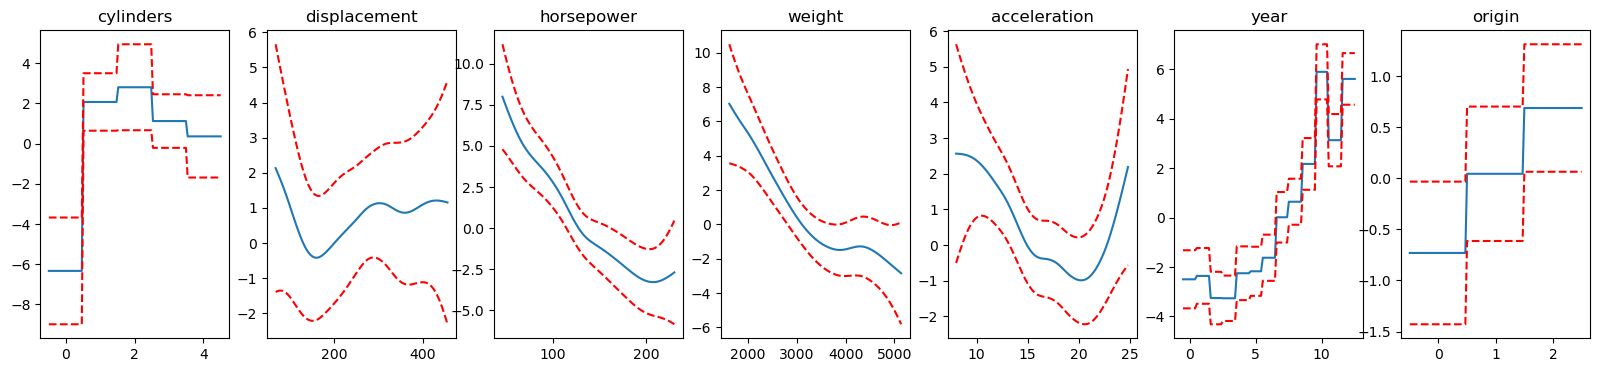

In [152]:
gamplot(full_gam, auto_train,all_cols,'mpg')

100% (100 of 100) |######################| Elapsed Time: 0:00:01 Time:  0:00:010000


Holdout MSE: 8.869363604132307


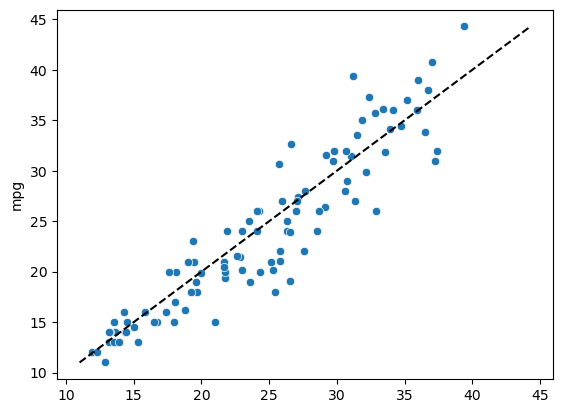

In [165]:
sub_cols = ['horsepower','year','weight']
sub_gam = gamfit(auto_train,sub_cols,'mpg')
sub_gam_predictions = sub_gam.predict(auto_test[sub_cols])
ho_sub_mse = mean_squared_error(sub_gam_predictions,auto_test['mpg'])
print(f'Holdout MSE: {ho_sub_mse}')
sns.scatterplot(x=sub_gam_predictions,y=auto_test['mpg']);
plt.plot([auto_test['mpg'].min(),auto_test['mpg'].max()],[auto_test['mpg'].min(),auto_test['mpg'].max()],'k--')
plt.show()

100% (100 of 100) |######################| Elapsed Time: 0:00:01 Time:  0:00:010000


Holdout MSE: 8.354575404966415


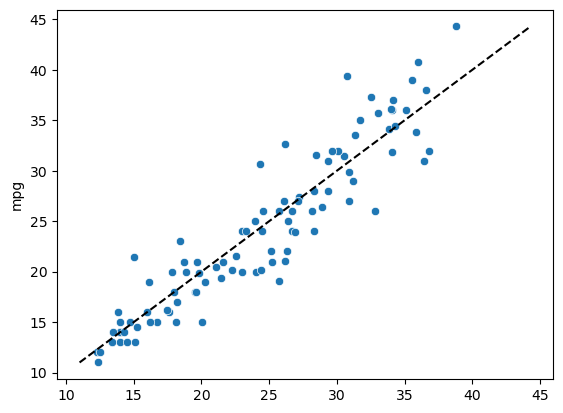

In [166]:
sub_cols = ['cylinders','horsepower','year','acceleration','weight']
sub_gam = gamfit(auto_train,sub_cols,'mpg')
sub_gam_predictions = sub_gam.predict(auto_test[sub_cols])
ho_sub_mse = mean_squared_error(sub_gam_predictions,auto_test['mpg'])
print(f'Holdout MSE: {ho_sub_mse}')
sns.scatterplot(x=sub_gam_predictions,y=auto_test['mpg']);
plt.plot([auto_test['mpg'].min(),auto_test['mpg'].max()],[auto_test['mpg'].min(),auto_test['mpg'].max()],'k--')
plt.show()

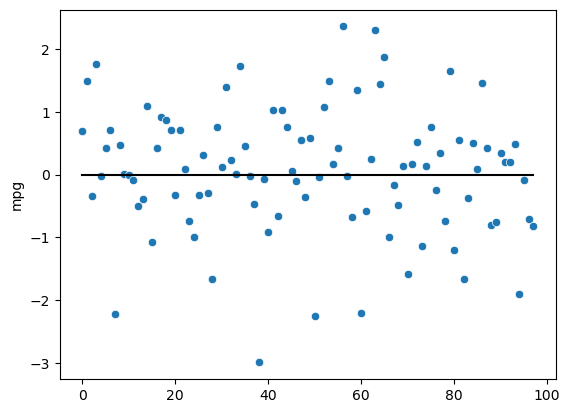

In [167]:
sub_resid = sub_gam_predictions-auto_test['mpg']
sub_resid /= sub_resid.std()
xs = np.arange(len(sub_resid))
sns.scatterplot(x=xs,y=sub_resid)
plt.plot(xs,[0]*len(xs),'k-')
plt.show()

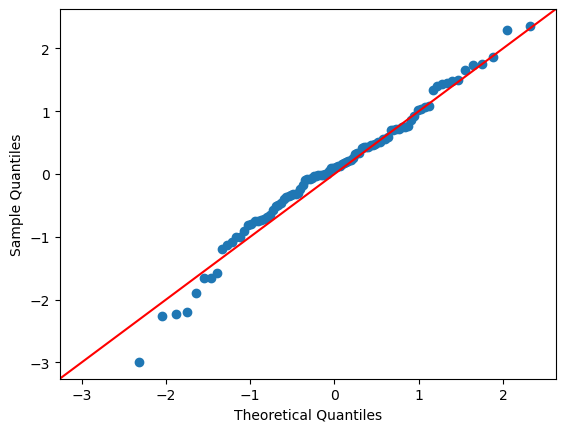

In [168]:
sm.qqplot(sub_resid,line='45')
plt.show()

CV average MSE: 0.1421
Cuts used: 16


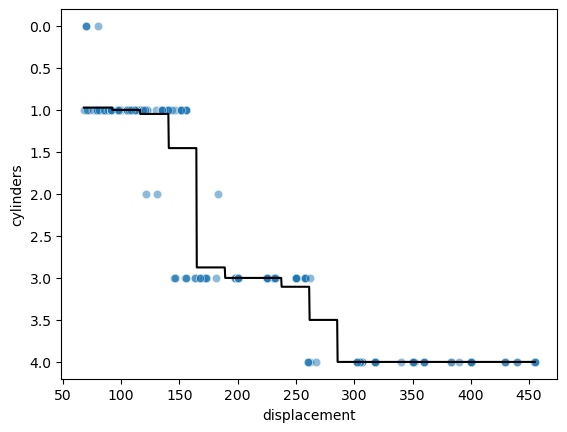

In [176]:
X = auto_train[['displacement']]
y = auto_train['cylinders']

pipe_step = Pipeline(
    [
        ('bin',KBinsDiscretizer(strategy='uniform')),('linreg',LinearRegression(fit_intercept=False))
    ]
)

inner_cv = KFold(shuffle=True,random_state=1728,n_splits=10)
outer_cv = KFold(shuffle=True,random_state=1729,n_splits=10)
cuts = np.arange(2,26)

gridsearch_step = GridSearchCV(pipe_step,{'bin__n_bins':cuts},scoring='neg_mean_squared_error',cv=inner_cv,n_jobs=-1)
cv_step_mse = -cross_val_score(gridsearch_step,X,y,cv=outer_cv).mean()

gridsearch_step.fit(X,y)
best_cuts = gridsearch_step.best_params_['bin__n_bins']

print(f'CV average MSE: {cv_step_mse:.4f}')
print(f'Cuts used: {best_cuts}')

pipe_step.named_steps['bin'].n_bins = best_cuts
pipe_step.fit(X.values,y)
xs = np.linspace(X.min(),X.max(),1000)
ys = pipe_step.predict(xs)

plt.plot(xs,ys,'k-')
sns.scatterplot(auto_no_na,x='displacement',y='cylinders',alpha=0.5)
plt.show()

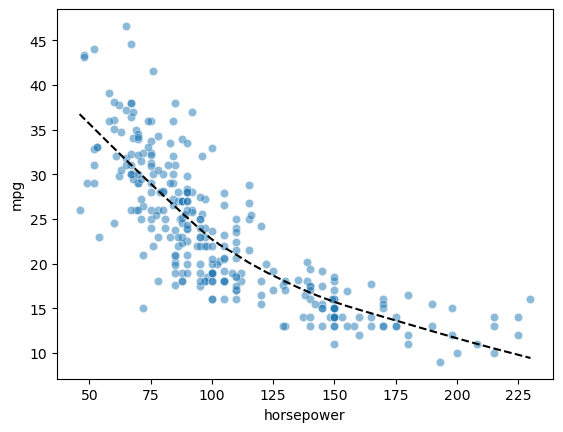

In [192]:
lowess_fit = sm.nonparametric.lowess(auto_train['mpg'],auto_train['horsepower'],frac=0.9)
sns.scatterplot(data = auto_train, x='horsepower',y='mpg',alpha=0.5)
plt.plot(lowess_fit[:,0],lowess_fit[:,1],'k--')
plt.show()